This notebook is a test for propagation of pure protons, with different interactions enabled/disabled

In [1]:
# Point PriNCe at the FLUKA-derived photo-nuclear database (v1).
# Built by prince-fluka-utils — replaces the SOPHIA + PEANUT/TALYS
# split. The path below is the production v1 build on SATORI; override
# config.fluka_db_path / config.fluka_db_fname for a different machine.
import prince_cr.config
prince_cr.config.fluka_db_path = '/ceph/sharedfs/work/SATORI/anatoli/devel/UH-UHECR-Fluka-Prince/runs/2026-05-04_pfu-v1-prod'
prince_cr.config.fluka_db_fname = 'prince_db_v1.h5'


CUPY not found for GPU support. Degrading to MKL.


In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import prince_cr.config
from prince_cr import core, util, photonfields, cross_sections
from prince_cr import util as pru

# Create a PriNCeRun object with max mass set to 1

In [4]:
%%time

prince_cr.config.max_mass = 1
prince_cr.config.secondaries = True
prince_cr.config.x_cut = 1e-6
prince_cr.config.x_cut_proton = 1e-3
# Format (log10(E_min), log10(E_max), nbins/decade of energy)
# Main energy grid for solver
prince_cr.config.cosmic_ray_grid = (3, 14, 8)
# Photon grid of target field, only for calculation of rates
prince_cr.config.photon_grid = (-15, -6, 8)
prince_cr.config.linear_algebra_backend = 'MKL'

pf = photonfields.CMBPhotonSpectrum()
cs = cross_sections.FlukaPhotoNuclear()
prince_run = core.PriNCeRun(max_mass=prince_cr.config.max_mass, photon_field=pf, cross_sections=cs)

PriNCeRun::__init__(): initialising Energy grid


PhotoNuclearInteractionRate::_init_coupling_mat(): Initiating coupling matrix in (CSR) format
CPU times: user 6.25 s, sys: 4.52 s, total: 10.8 s
Wall time: 5.58 s


# Run solvers with different interactions enabled

In [5]:
%%time
from prince_cr.solvers import UHECRPropagationSolverETD2 as SolClass
from prince_cr.cr_sources import SimpleSource

initial_z = 1.
final_z = 0.
norm = 1.
source = SimpleSource(prince_run,params={2212: (2.5,1e12,1.)}, norm=1.,m=0.)

sol_adiabatic = SolClass(initial_z=initial_z, final_z =final_z,prince_run=prince_run,
                         enable_pairprod_losses = False,
                         enable_adiabatic_losses = True,
                         enable_photohad_losses = False)
sol_adiabatic.add_source_class(source)

sol_pairprod = SolClass(initial_z=initial_z, final_z =final_z,prince_run=prince_run,
                        enable_pairprod_losses = True,
                        enable_adiabatic_losses = True,
                        enable_photohad_losses = False)
sol_pairprod.add_source_class(source)

sol_photohad = SolClass(initial_z=initial_z, final_z =final_z,prince_run=prince_run,
                        enable_pairprod_losses = False,
                        enable_adiabatic_losses = True,
                        enable_photohad_losses = True)
sol_photohad.add_source_class(source)

sol_alllosses = SolClass(initial_z=initial_z, final_z =final_z,prince_run=prince_run,
                         enable_pairprod_losses = True,
                         enable_adiabatic_losses = True,
                         enable_photohad_losses = True)
sol_alllosses.add_source_class(source)

for solver in [sol_adiabatic, sol_pairprod, sol_photohad, sol_alllosses]:
    solver.solve(dz=1e-3,verbose=False, progressbar=True)
    print(solver.list_of_sources)
    print('finished solving for', str(solver))

solver_d2 = [sol_adiabatic, sol_pairprod, sol_photohad, sol_alllosses]

finished solving for <prince_cr.solvers.propagation.UHECRPropagationSolverETD2 object at 0x7faaf6e36900>


finished solving for <prince_cr.solvers.propagation.UHECRPropagationSolverETD2 object at 0x7faaf722b250>


finished solving for <prince_cr.solvers.propagation.UHECRPropagationSolverETD2 object at 0x7faaf722b390>


finished solving for <prince_cr.solvers.propagation.UHECRPropagationSolverETD2 object at 0x7faaf722b750>
CPU times: user 53.9 s, sys: 39 ms, total: 53.9 s
Wall time: 1.73 s


# Normalize and plot the results

In [6]:
results = []
for solver in [sol_adiabatic, sol_pairprod, sol_photohad, sol_alllosses]:
    result = solver.res
    egrid, spec = result.get_solution_group('CR')
    norm = 1e2/spec[(np.abs(egrid - 1e8)).argmin()]
    print(f'{norm:.2e}')
    
    result = result * norm
    results.append(result)

res_adiabatic, res_pairprod, res_photohad, res_alllosses = results

2.08e-20
2.08e-20
2.08e-20
2.08e-20


/tmp/ipykernel_784208/2133288461.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(ncol=3)#, fontsize='xx-small')


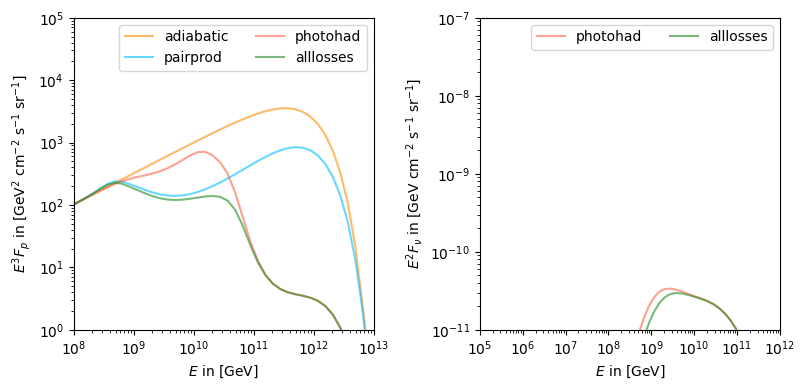

In [7]:
fig, ax = plt.subplots(1,2, figsize = (8,4))

#----------------------------------------------
# compare contributions cosmic rays
#----------------------------------------------
plt.sca(ax[0])

for (result, label, color) in zip([res_adiabatic, res_pairprod, res_photohad, res_alllosses],
                                  ['adiabatic', 'pairprod', 'photohad', 'alllosses'],
                                  ['darkorange','deepskyblue','tomato','forestgreen']):
    energy, spectrum = result.get_solution_scale(2212,epow=3)
    l = plt.loglog(energy, spectrum, label=label, c=color, alpha = 0.6)

plt.legend(ncol=2)#, fontsize='xx-small')

plt.ylabel(r'$E^3 F_p$ in [GeV$^2$ cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.ylim(1e0,1e5)
plt.xlabel(r'$E$ in [GeV]')
plt.xlim(1e8,1e13)

#----------------------------------------------
# compare contributions neutrinos
#----------------------------------------------
plt.sca(ax[1])

plt.loglog()
plt.legend(ncol=3)#, fontsize='xx-small')

for (result, label, color) in zip([
    res_photohad, res_alllosses],
                                  ['photohad', 'alllosses'],
                                  ['tomato','forestgreen']):
    energy, spectrum = result.get_solution_group([12,-12,14,-14],epow=2)
    l = plt.loglog(energy, spectrum, label=label, c=color, alpha = 0.6)

plt.legend(ncol=2)#, fontsize='xx-small')

plt.ylabel(r'$E^2 F_\nu$ in [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.ylim(1e-11,1e-7)
plt.xlim(1e5,1e12)
plt.xlabel(r'$E$ in [GeV]')

plt.tight_layout()

# Exact adiabatic solution:

The adaibatic solution at $z = 0$ is simply calculated by integration of the injection:
$$
n(E, z = 0) = \int_0^{z_{max}} dz^\prime \frac{1}{H(z^\prime)} \mathcal{L}_{inj}(\epsilon (1 + z^\prime), z^\prime)
$$

This results should be retained by the solver that has only adiabatic losses enabled.

In [8]:
%%time
from prince_cr.solvers import UHECRPropagationSolverETD2 as SolClass
from prince_cr.cr_sources import SimpleSource

initial_z = 1.
final_z = 0.
norm = 1.
source = SimpleSource(prince_run,params={2212: (2.5,1e12,1.)}, norm=1.,m=0.)

sol_adiabatic = SolClass(initial_z=initial_z, final_z =final_z,prince_run=prince_run,
                         enable_pairprod_losses = False,
                         enable_adiabatic_losses = True,
                         enable_photohad_losses = False,
                        enable_partial_diff_jacobian=True)
sol_adiabatic.add_source_class(source)

sol_adiabatic.solve(dz=1e-3,verbose=False)

CPU times: user 13.2 s, sys: 17.6 ms, total: 13.2 s
Wall time: 423 ms


CPU times: user 24.2 s, sys: 348 ms, total: 24.5 s
Wall time: 21.4 s


(1e+20, 1e+24)

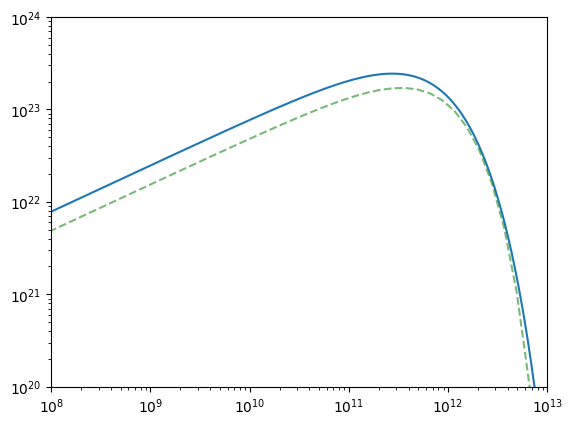

In [9]:
%%time

source = SimpleSource(prince_run,params={2212: (2.5, 1e12, 1.)}, norm=1.,m=0.)

injection = source.injection_rate_single
injection = np.vectorize(injection,excluded=[0])

egrid = np.logspace(8,13,2112)
z_steps = np.linspace(0,5,2112)

from prince_cr.cosmology import H
from scipy.integrate import trapezoid as trapz

einj = np.outer(egrid, 1 + z_steps)
z_prime = np.outer(1, z_steps)
inj = injection(2212,einj, z_prime)
H_factor = H(z_prime)

spectrum = trapz(inj / H_factor, z_steps ,axis = 1)

plt.loglog(egrid, egrid**3 * spectrum)

energy, spectrum = sol_adiabatic.res.get_solution_scale(2212,epow=3)
plt.loglog(energy, spectrum, label=label, c=color, alpha = 0.6,ls='dashed')

plt.xlim(1e8,1e13)
plt.ylim(1e20,1e24)